#  IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

# LOAD DATASET

In [3]:
SP = pd.read_csv('C:\\Users\Jide Falowo\Desktop\Dataset J\\StudentsPerformance.csv')
SP.head(100)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


# BASIC INFORMATION

In [4]:
SP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


#  CHECK FOR MISSING VALUES

In [5]:
missing_values = SP.isnull().sum()
missing_values

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# CHECK NUMBER OF ROWS AND COLUMNS

In [7]:
rows, columns = SP.shape

print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 1000
Number of columns: 8


# COLUMN NAMES

In [8]:
print("Column Names:")

for column in SP.columns:
    print(column)

Column Names:
gender
race/ethnicity
parental level of education
lunch
test preparation course
math score
reading score
writing score


# CHECK FOR DUPLICATES

In [9]:
duplicates = SP.duplicated().sum()
("Number of duplicate rows:", duplicates)

('Number of duplicate rows:', 0)

# REMOVE DUPLICATES

In [10]:
SP = SP.drop_duplicates()
("Shape after removing duplicates:", SP.shape)

('Shape after removing duplicates:', (1000, 8))

# DESCRIPTIVE STATISTICS

In [11]:
SP.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# CHECK UNIQUE VALUES

In [12]:
categorical_columns = SP.select_dtypes(include="object").columns

for column in categorical_columns:
    print("\n", "=" * 60)
    print(f"{column}")
    print("=" * 60)
    print(SP[column].unique())


gender
['female' 'male']

race/ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']

parental level of education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

lunch
['standard' 'free/reduced']

test preparation course
['none' 'completed']


# CREATE TOTAL SCORE

In [13]:
SP["total_score"] = (
    SP["math score"] +
    SP["reading score"] +
    SP["writing score"]
)

SP["average_score"] = SP["total_score"] / 3

SP.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
5,female,group B,associate's degree,standard,none,71,83,78,232,77.333333
6,female,group B,some college,standard,completed,88,95,92,275,91.666667
7,male,group B,some college,free/reduced,none,40,43,39,122,40.666667
8,male,group D,high school,free/reduced,completed,64,64,67,195,65.000000
9,female,group B,high school,free/reduced,none,38,60,50,148,49.333333


# CREATE PERFORMANCE CATEGORY

In [14]:
def performance_category(score):
    if score >= 80:
        return "Excellent"
    elif score >= 70:
        return "Very Good"
    elif score >= 60:
        return "Good"
    elif score >= 50:
        return "Average"
    else:
        return "Poor"

SP["performance_category"] = SP["average_score"].apply( performance_category)

SP.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score,performance_category
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Very Good
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Excellent
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Poor
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Very Good
5,female,group B,associate's degree,standard,none,71,83,78,232,77.333333,Very Good
6,female,group B,some college,standard,completed,88,95,92,275,91.666667,Excellent
7,male,group B,some college,free/reduced,none,40,43,39,122,40.666667,Poor
8,male,group D,high school,free/reduced,completed,64,64,67,195,65.000000,Good
9,female,group B,high school,free/reduced,none,38,60,50,148,49.333333,Poor


# CREATE PASS/FAIL STATUS

In [15]:
SP["pass_status"] = np.where(
    (SP["math score"] >= 50) &
    (SP["reading score"] >= 50) &
    (SP["writing score"] >= 50),
    "Pass",
    "Fail"
)

SP["pass_status"].value_counts()


pass_status
Pass    812
Fail    188
Name: count, dtype: int64

# EXPLORATORY DATA ANALYSIS EDA

# Gender Distribution

In [16]:
gender_count = SP["gender"].value_counts()
gender_count

gender
female    518
male      482
Name: count, dtype: int64

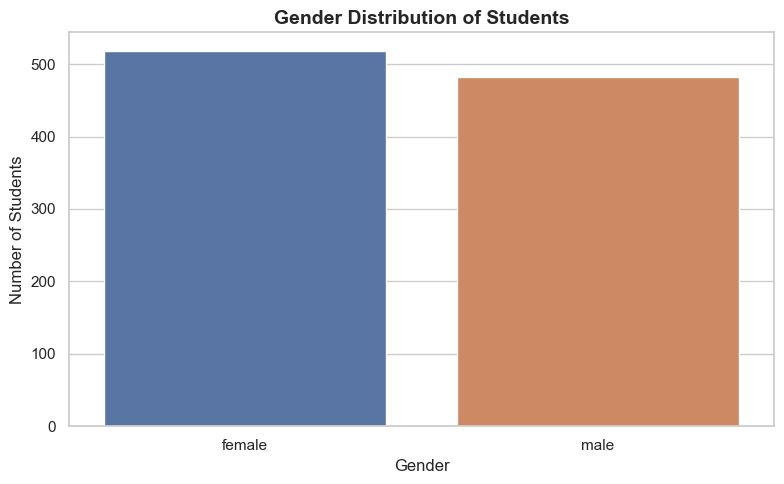

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(data=SP,x="gender")

plt.title("Gender Distribution of Students", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# Gender Percentage

In [18]:
gender_percentage = ( SP["gender"].value_counts(normalize=True) * 100)
gender_percentage.round(2)

gender
female    51.8
male      48.2
Name: proportion, dtype: float64

# Race/Ethnicity Distribution

In [19]:
race_count = SP["race/ethnicity"].value_counts()

(race_count)

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

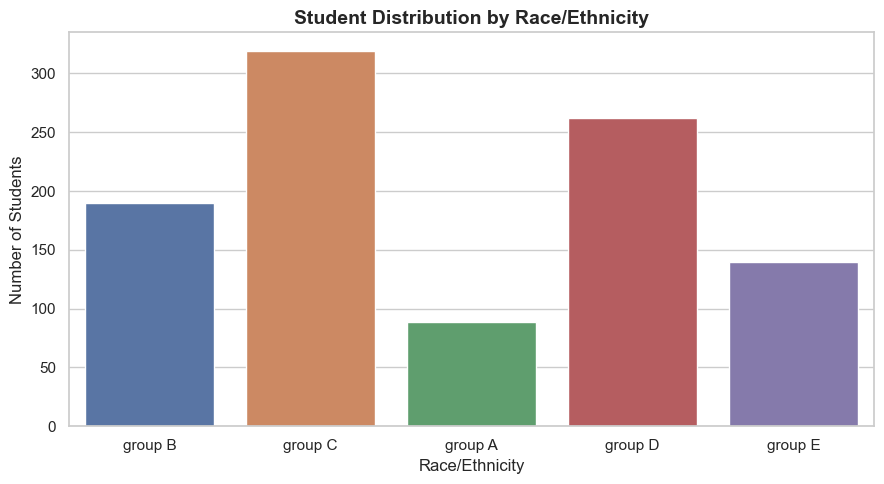

In [20]:
plt.figure(figsize=(9, 5))

sns.countplot(data=SP,x="race/ethnicity")

plt.title("Student Distribution by Race/Ethnicity",fontsize=14,fontweight="bold")

plt.xlabel("Race/Ethnicity")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# Parental Education

In [21]:
parent_education = SP["parental level of education"].value_counts()

parent_education

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

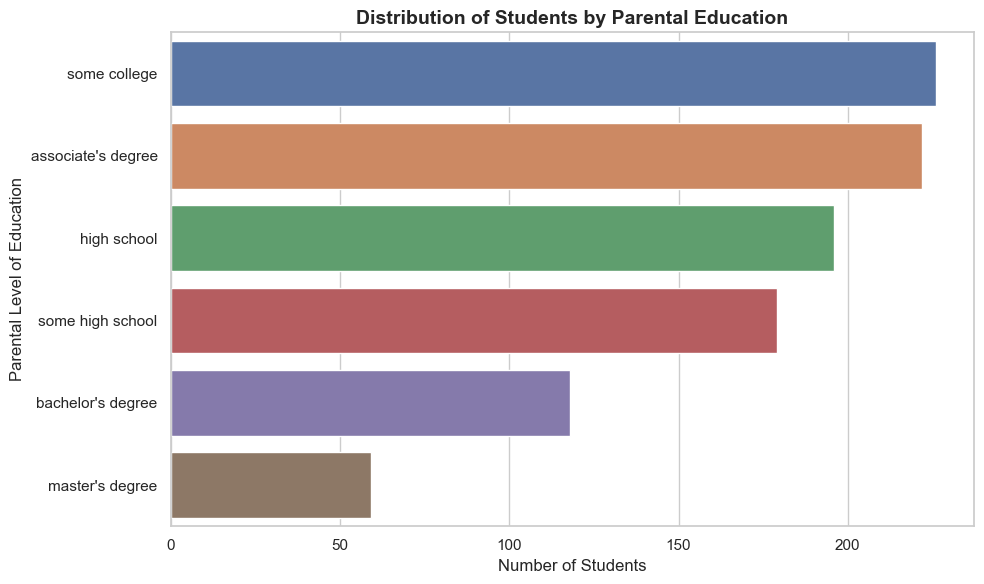

In [22]:
plt.figure(figsize=(10, 6))

sns.countplot(data=SP,y="parental level of education",order=SP["parental level of education"].value_counts().index)

plt.title("Distribution of Students by Parental Education",fontsize=14,fontweight="bold")

plt.xlabel("Number of Students")
plt.ylabel("Parental Level of Education")

plt.tight_layout()
plt.show()

# Lunch Type

In [23]:
lunch_count = SP["lunch"].value_counts()

lunch_count

lunch
standard        645
free/reduced    355
Name: count, dtype: int64

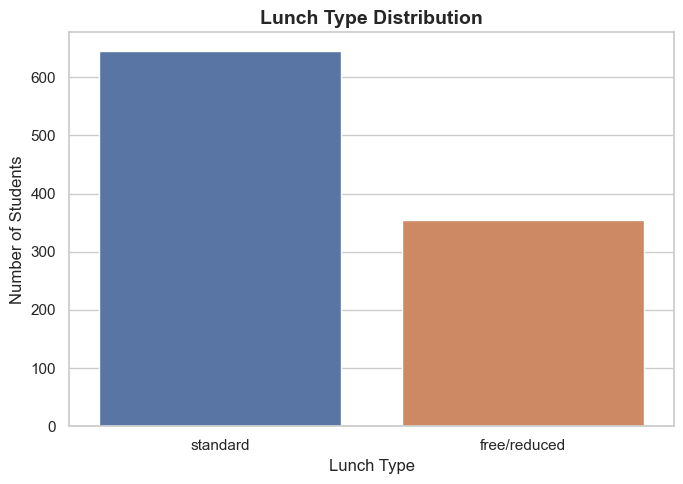

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot( data=SP, x="lunch")

plt.title("Lunch Type Distribution",fontsize=14,fontweight="bold")

plt.xlabel("Lunch Type")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# Test Preparation

In [25]:
test_prep = SP["test preparation course"].value_counts()

test_prep

test preparation course
none         642
completed    358
Name: count, dtype: int64

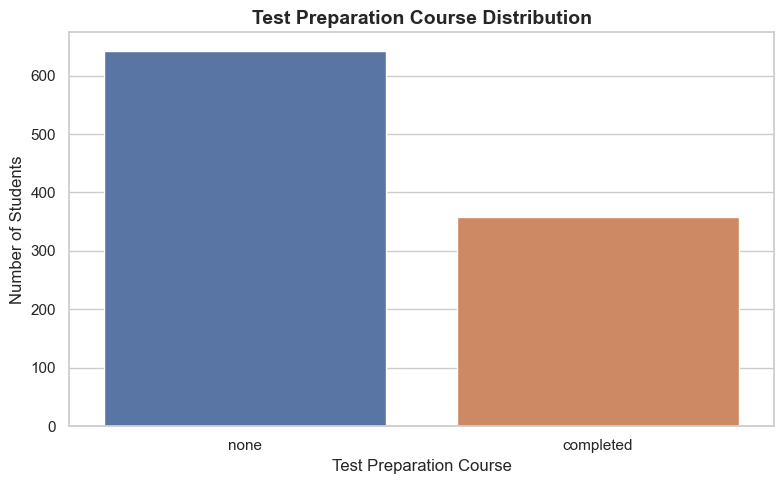

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(data=SP, x="test preparation course")

plt.title("Test Preparation Course Distribution",fontsize=14,fontweight="bold")

plt.xlabel("Test Preparation Course")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# SUBJECT PERFORMANCE

# Average Scores

In [27]:
subject_columns = [
    "math score",
    "reading score",
    "writing score"
]

average_scores = SP[subject_columns].mean()

print("Average scores:")
display(average_scores.round(2))

Average scores:


math score       66.09
reading score    69.17
writing score    68.05
dtype: float64

# Average Score Bar Chart

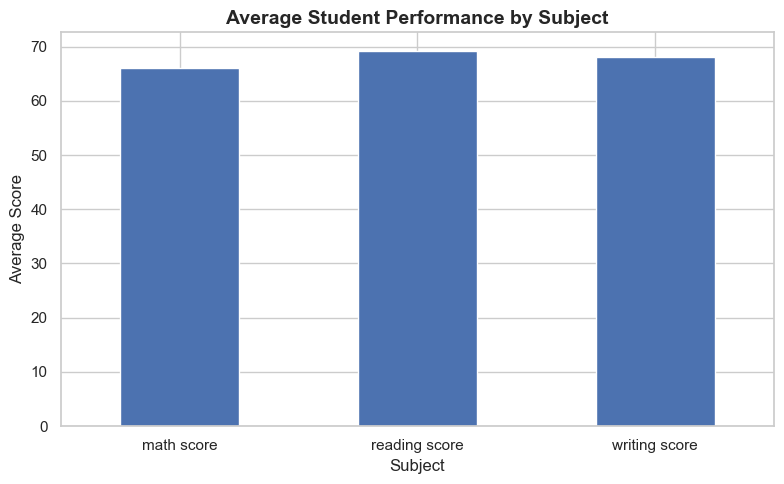

In [28]:
plt.figure(figsize=(8, 5))

average_scores.plot(kind="bar")

plt.title( "Average Student Performance by Subject", fontsize=14, fontweight="bold")

plt.xlabel("Subject")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Distribution of Math Scores

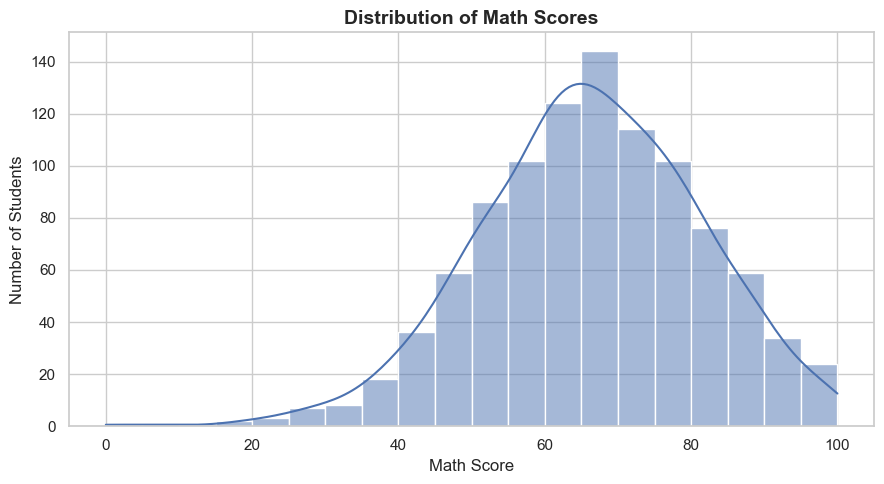

In [29]:
plt.figure(figsize=(9, 5))

sns.histplot(data=SP,x="math score",bins=20, kde=True)

plt.title("Distribution of Math Scores",fontsize=14,fontweight="bold")

plt.xlabel("Math Score")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# Distribution of Reading Scores

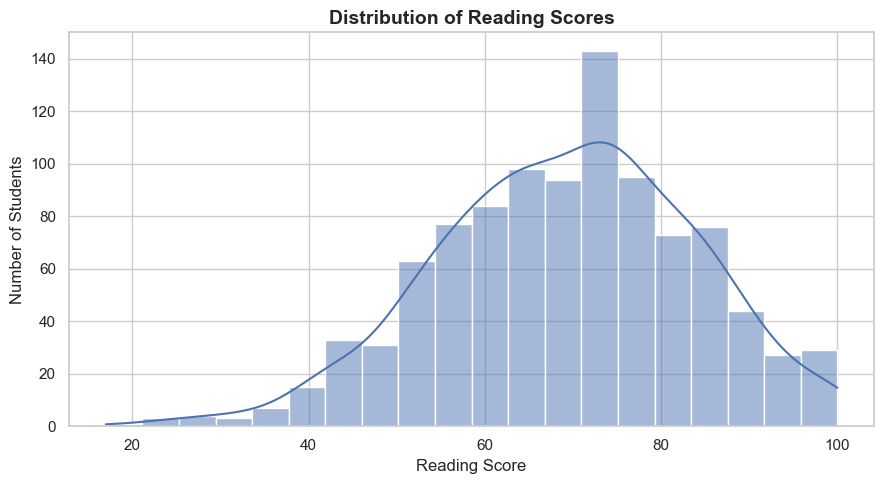

In [30]:
plt.figure(figsize=(9, 5))

sns.histplot( data=SP, x="reading score", bins=20, kde=True)

plt.title("Distribution of Reading Scores",fontsize=14,fontweight="bold")

plt.xlabel("Reading Score")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# Distribution of Writing Scores

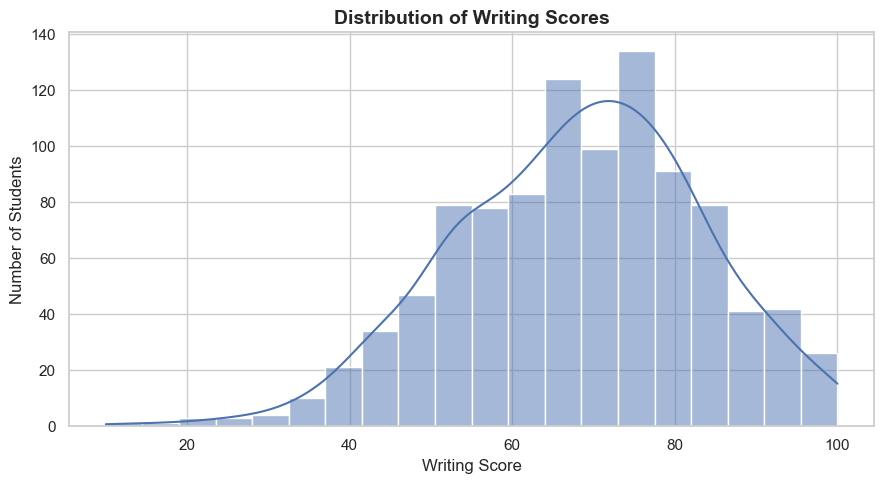

In [31]:
plt.figure(figsize=(9, 5))

sns.histplot(data=SP,x="writing score",bins=20,kde=True)

plt.title("Distribution of Writing Scores",fontsize=14,fontweight="bold")

plt.xlabel("Writing Score")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

# SUBJECT COMPARISON

# Boxplot of All Subjects

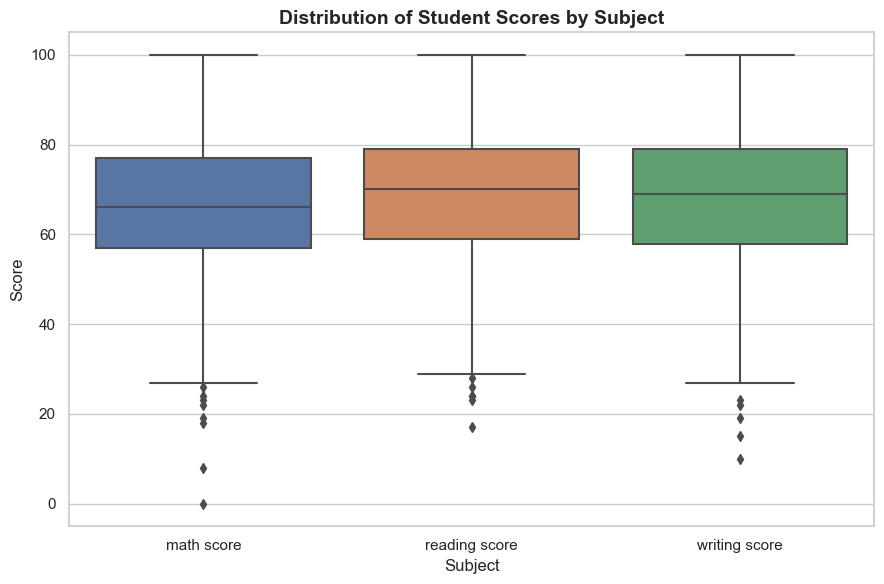

In [32]:
plt.figure(figsize=(9, 6))

sns.boxplot(data=SP[["math score", "reading score", "writing score"]])

plt.title("Distribution of Student Scores by Subject",fontsize=14,fontweight="bold")

plt.xlabel("Subject")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

# Math vs Reading

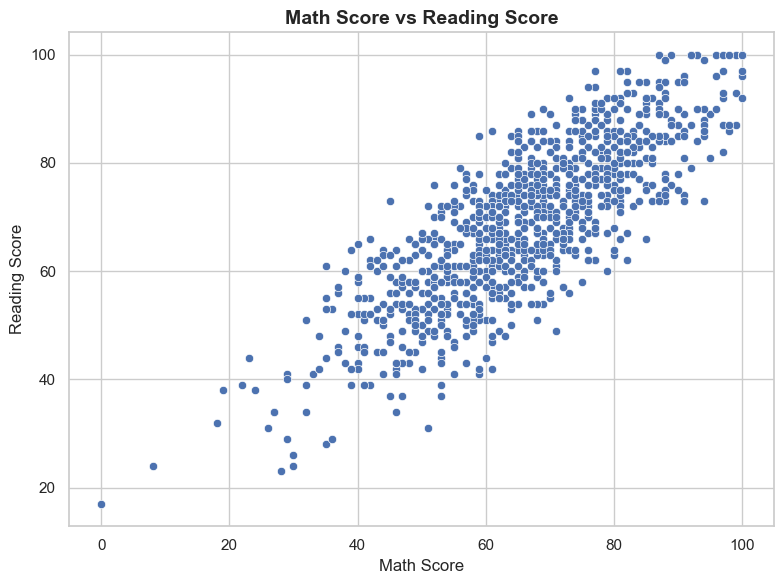

In [33]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=SP,x="math score",y="reading score")

plt.title("Math Score vs Reading Score",fontsize=14,fontweight="bold")

plt.xlabel("Math Score")
plt.ylabel("Reading Score")

plt.tight_layout()
plt.show()

# Math vs Writing

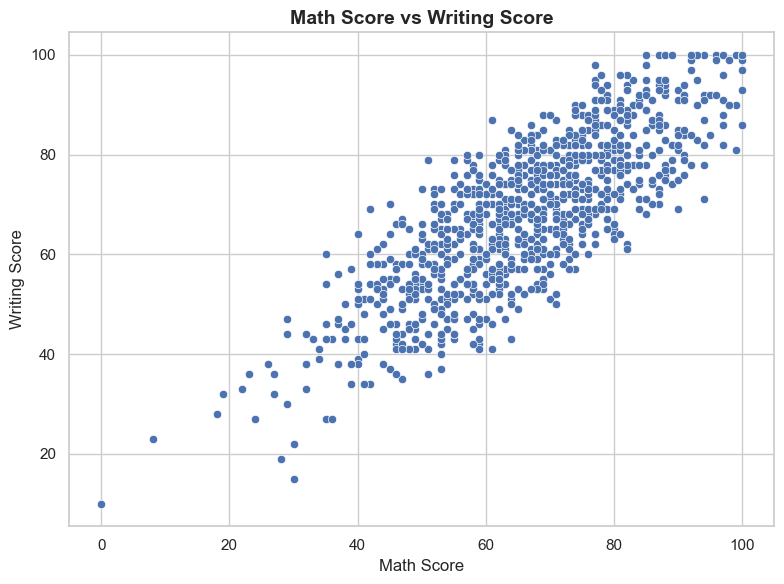

In [34]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=SP,x="math score",y="writing score")

plt.title("Math Score vs Writing Score",fontsize=14,fontweight="bold")

plt.xlabel("Math Score")
plt.ylabel("Writing Score")

plt.tight_layout()
plt.show()

# Reading vs Writing

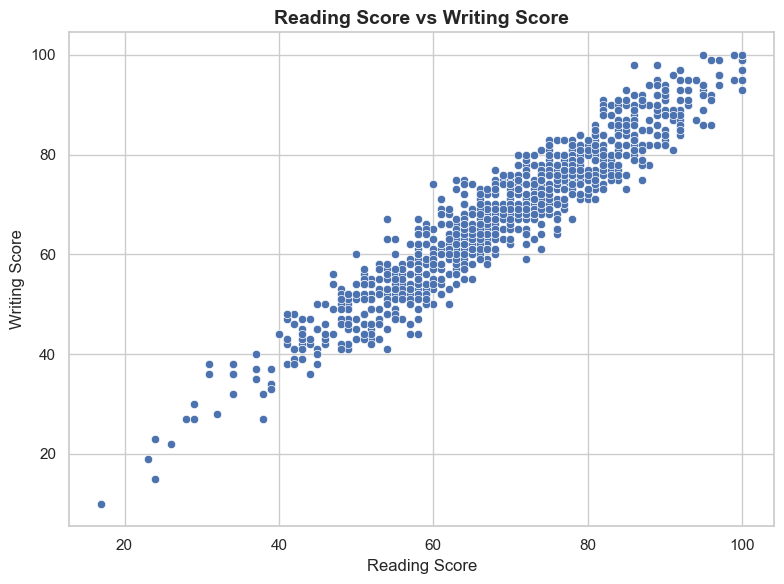

In [35]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=SP,x="reading score",y="writing score")

plt.title("Reading Score vs Writing Score",fontsize=14,fontweight="bold")

plt.xlabel("Reading Score")
plt.ylabel("Writing Score")

plt.tight_layout()
plt.show()

# GROUP ANALYSIS

# Performance by Gender

In [36]:
gender_performance = SP.groupby("gender")[
    ["math score", "reading score", "writing score"]
].mean()

gender_performance.round(2)

,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


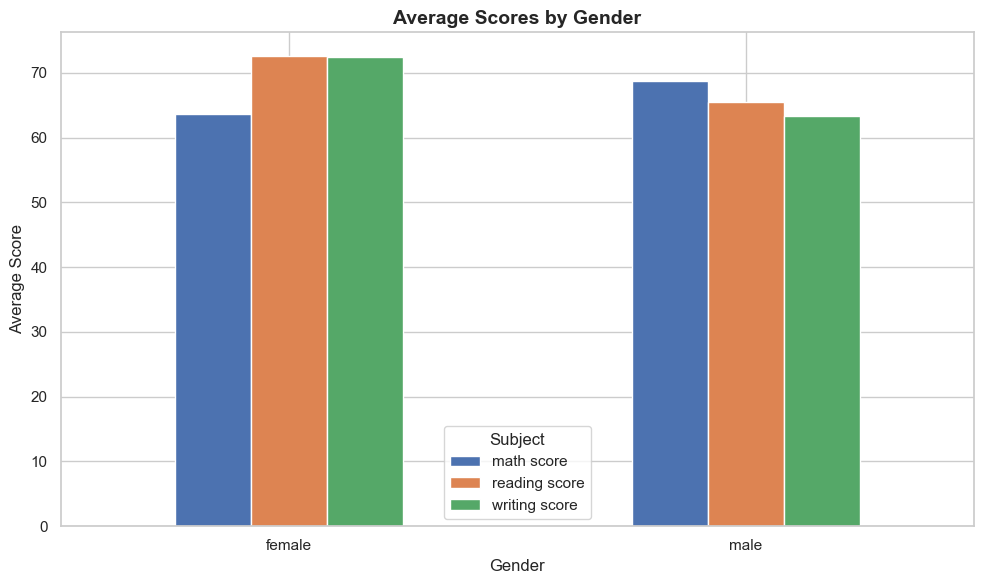

In [37]:
gender_performance.plot(kind="bar",figsize=(10, 6))

plt.title("Average Scores by Gender",fontsize=14,fontweight="bold")

plt.xlabel("Gender")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.legend(title="Subject")

plt.tight_layout()
plt.show()

# Performance by Race/Ethnicity

In [38]:
race_performance = SP.groupby("race/ethnicity")[
    ["math score", "reading score", "writing score"]
].mean()

race_performance.round(2)

,math score,reading score,writing score
race/ethnicity,,,
group A,61.63,64.67,62.67
group B,63.45,67.35,65.60
group C,64.46,69.10,67.83
group D,67.36,70.03,70.15
group E,73.82,73.03,71.41


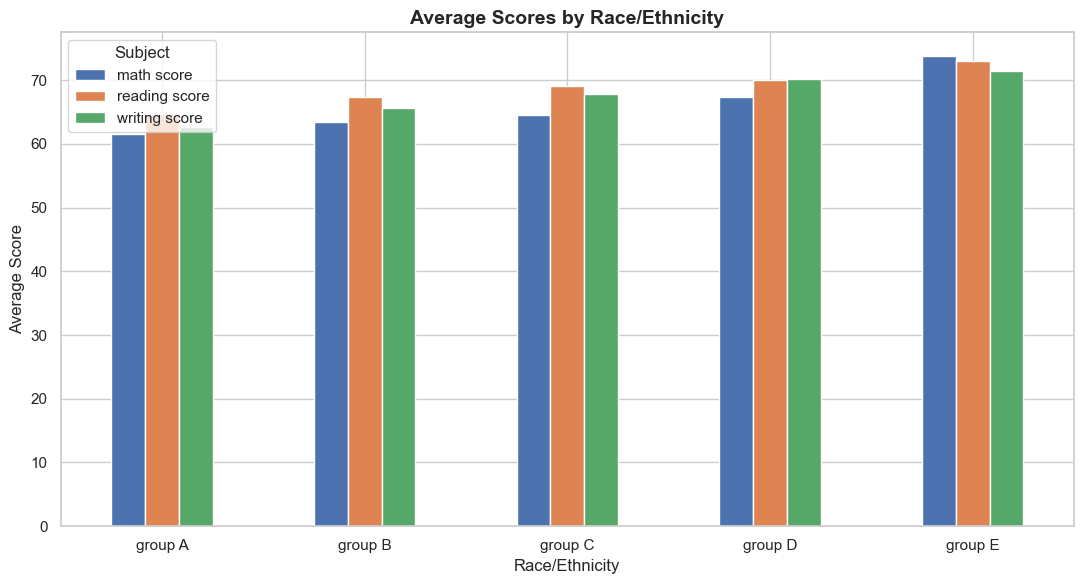

In [39]:
race_performance.plot(kind="bar",figsize=(11, 6))

plt.title("Average Scores by Race/Ethnicity",fontsize=14,fontweight="bold")

plt.xlabel("Race/Ethnicity")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.legend(title="Subject")

plt.tight_layout()
plt.show()

# Performance by Parental Education

In [40]:
parent_performance = SP.groupby(
    "parental level of education"
)[
    ["math score", "reading score", "writing score"]
].mean()

parent_performance.round(2)

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.88,70.93,69.90
bachelor's degree,69.39,73.00,73.38
high school,62.14,64.70,62.45
master's degree,69.75,75.37,75.68
some college,67.13,69.46,68.84
some high school,63.50,66.94,64.89


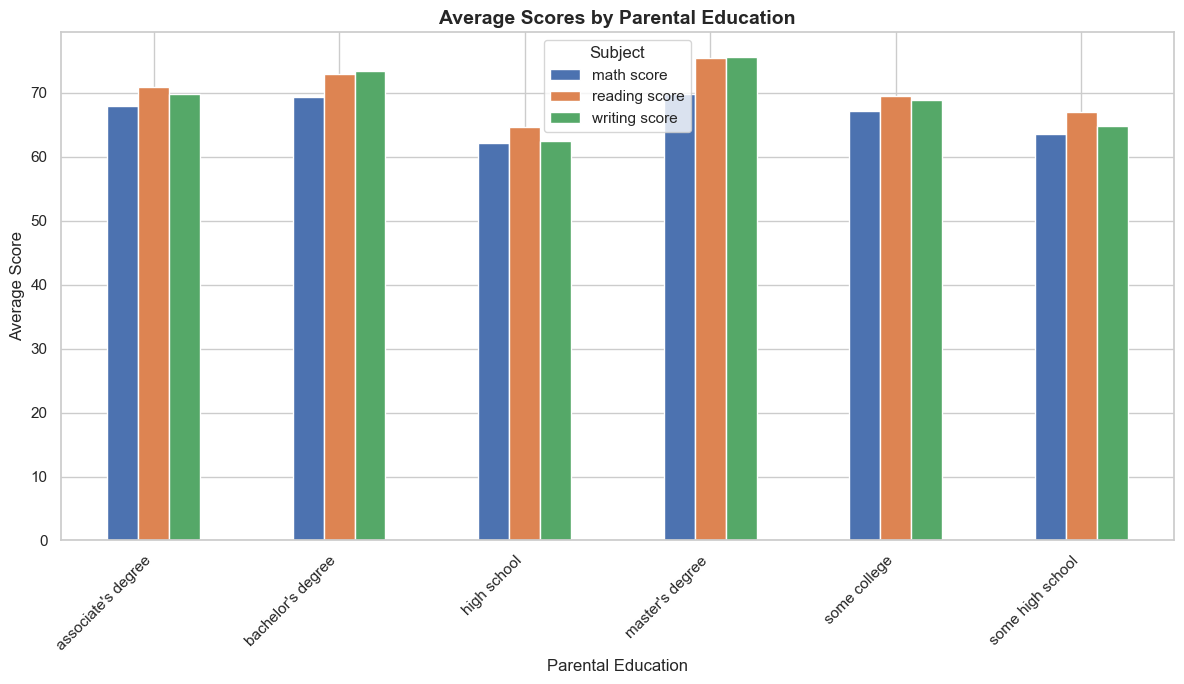

In [41]:
parent_performance.plot(kind="bar",figsize=(12, 7))

plt.title("Average Scores by Parental Education",fontsize=14,fontweight="bold")

plt.xlabel("Parental Education")
plt.ylabel("Average Score")

plt.xticks(rotation=45, ha="right")

plt.legend(title="Subject")

plt.tight_layout()
plt.show()

# Performance by Lunch

In [42]:
lunch_performance = SP.groupby("lunch")[
    ["math score", "reading score", "writing score"]
].mean()

lunch_performance.round(2)

,math score,reading score,writing score
lunch,,,
free/reduced,58.92,64.65,63.02
standard,70.03,71.65,70.82


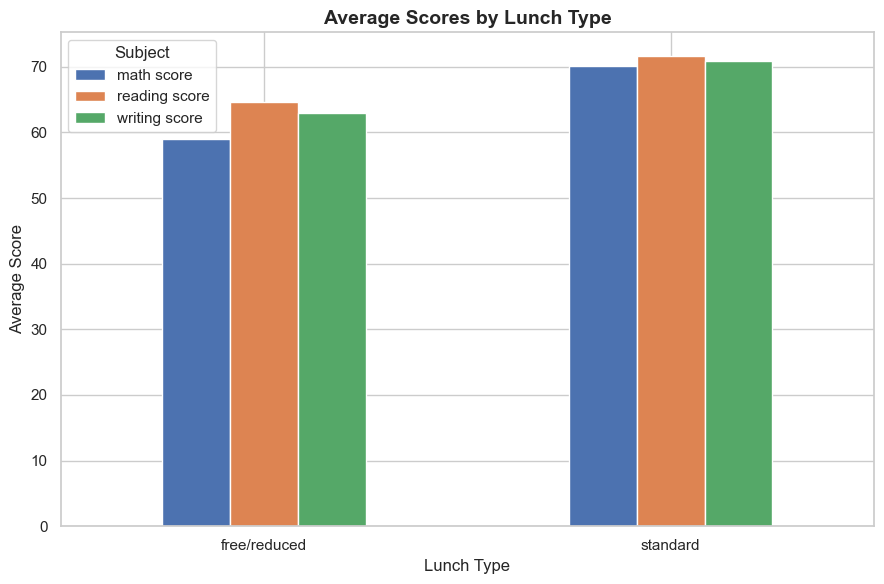

In [43]:
lunch_performance.plot(kind="bar",figsize=(9, 6))

plt.title("Average Scores by Lunch Type",fontsize=14,fontweight="bold")

plt.xlabel("Lunch Type")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.legend(title="Subject")

plt.tight_layout()
plt.show()

# Test Preparation vs Performance

In [44]:
test_prep_performance = SP.groupby(
    "test preparation course"
)[
    ["math score", "reading score", "writing score"]
].mean()

test_prep_performance.round(2)

,math score,reading score,writing score
test preparation course,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


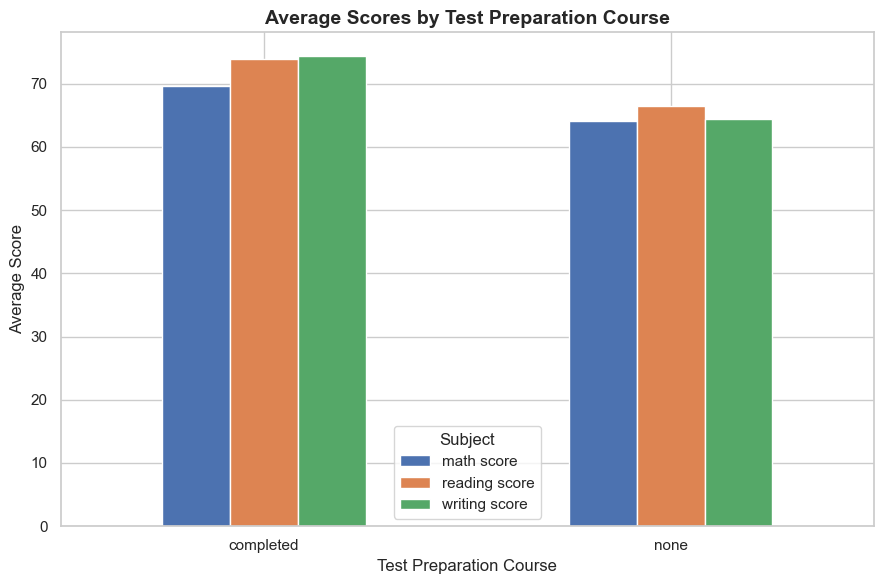

In [45]:
test_prep_performance.plot(kind="bar",figsize=(9, 6))

plt.title("Average Scores by Test Preparation Course",fontsize=14,fontweight="bold")

plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.legend(title="Subject")

plt.tight_layout()
plt.show()

# TOTAL AND AVERAGE PERFORMANCE

# Overall Performance

In [47]:
print(SP.columns.tolist())

['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score', 'total_score', 'average_score', 'performance_category', 'pass_status']


In [48]:
SP["average score"] = SP[["math score", "reading score", "writing score"]].mean(axis=1)

print("Overall average score:",
      round(SP["average score"].mean(), 2))


print("Highest average score:",
      round(SP["average score"].max(), 2))

print("Lowest average score:", 
      round(SP["average score"].min(), 2))

Overall average score: 67.77
Highest average score: 100.0
Lowest average score: 9.0


# Top 10 Students

In [49]:
top_10_students = SP.sort_values("average score", ascending=False).head(10)

display(top_10_students[
        [
            "gender",
            "race/ethnicity",
            "parental level of education",
            "math score",
            "reading score",
            "writing score",
            "average score"
        ]
    ]
)

,gender,race/ethnicity,parental level of education,math score,reading score,writing score,average score
916,male,group E,bachelor's degree,100,100,100,100.000000
458,female,group E,bachelor's degree,100,100,100,100.000000
962,female,group E,associate's degree,100,100,100,100.000000
114,female,group E,bachelor's degree,99,100,100,99.666667
179,female,group D,some high school,97,100,100,99.000000
712,female,group D,some college,98,100,99,99.000000
165,female,group C,bachelor's degree,96,100,100,98.666667
625,male,group D,some college,100,97,99,98.666667
903,female,group D,bachelor's degree,93,100,100,97.666667
149,male,group E,associate's degree,100,100,93,97.666667


# Bottom 10 Students

In [50]:
bottom_10_students = SP.sort_values("average score",ascending=True).head(10)

display( bottom_10_students[
        [
            "gender",
            "race/ethnicity",
            "parental level of education",
            "math score",
            "reading score",
            "writing score",
            "average score"
        ]
    ]
)

,gender,race/ethnicity,parental level of education,math score,reading score,writing score,average score
59,female,group C,some high school,0,17,10,9.000000
980,female,group B,high school,8,24,23,18.333333
596,male,group B,high school,30,24,15,23.000000
327,male,group A,some college,28,23,19,23.333333
76,male,group E,some high school,30,26,22,26.000000
17,female,group B,some high school,18,32,28,26.000000
601,female,group C,high school,29,29,30,29.333333
787,female,group B,some college,19,38,32,29.666667
338,female,group B,some high school,24,38,27,29.666667
211,male,group C,some college,35,28,27,30.000000


# PERFORMANCE CATEGORIES

# Performance Category Distribution

In [51]:
SP["performance_category"] = SP[['math score', 'reading score', 'writing score']].apply(lambda x: "High" if x.mean() >= 70 else "Low", axis=1)
performance_counts = SP["performance_category"].value_counts()
performance_counts

performance_category
Low     541
High    459
Name: count, dtype: int64

In [52]:
print(performance_counts)

performance_category
Low     541
High    459
Name: count, dtype: int64


In [53]:
SP[["math score", "reading score", "writing score"]].head()

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


performance_category
Very Good    472
Good         302
Excellent    168
Average       52
Poor           6
Name: count, dtype: int64


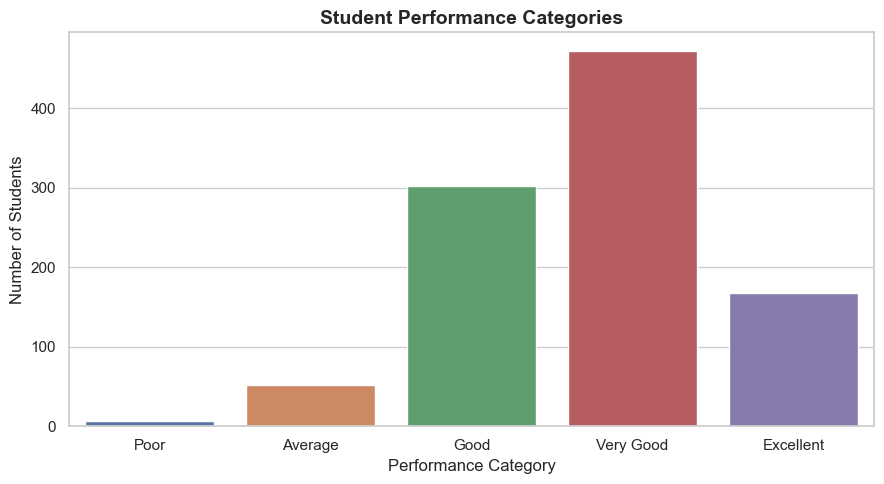

In [56]:

SP["performance_category"] = pd.cut(
    SP["average_score"],
    bins=5,
    labels=["Poor", "Average", "Good", "Very Good", "Excellent"],
    right=False
)

print(SP["performance_category"].value_counts())

plt.figure(figsize=(9, 5))

sns.countplot(
    data=SP,
    x="performance_category",
    order=["Poor", "Average", "Good", "Very Good", "Excellent"]
)

plt.title("Student Performance Categories", fontsize=14, fontweight="bold")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

In [58]:
performance_percentage = (
    SP['performance_category']
    .value_counts(normalize=True)
    .reindex(["Poor", "Average", "Good", "Very Good", "Excellent"])
    * 100
)

print(performance_percentage.round(2))

performance_category
Poor          0.6
Average       5.2
Good         30.2
Very Good    47.2
Excellent    16.8
Name: proportion, dtype: float64


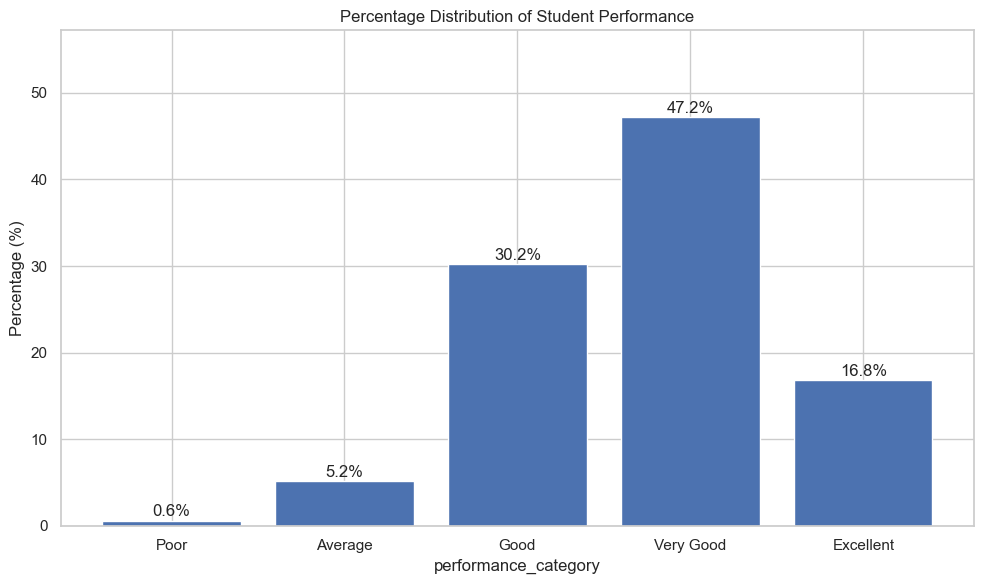

In [62]:
performance_percentage = (
    SP["performance_category"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    performance_percentage.index,
    performance_percentage.values
)

plt.title("Percentage Distribution of Student Performance")
plt.xlabel("performance_category")
plt.ylabel("Percentage (%)")


for i, value in enumerate(performance_percentage.values):
    plt.text(
        i,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.xticks(rotation=0)
plt.ylim(0, max(performance_percentage.values) + 10)

plt.tight_layout()
plt.show()

# Pass/Fail Analysis

In [63]:
SP['pass_status'] = np.where(
    (SP['math score'] >= 50) &
    (SP['reading score'] >= 50) &
    (SP['writing score'] >= 50),
    'Pass',
    'Fail'
)

SP['pass_status'].value_counts()

pass_status
Pass    812
Fail    188
Name: count, dtype: int64

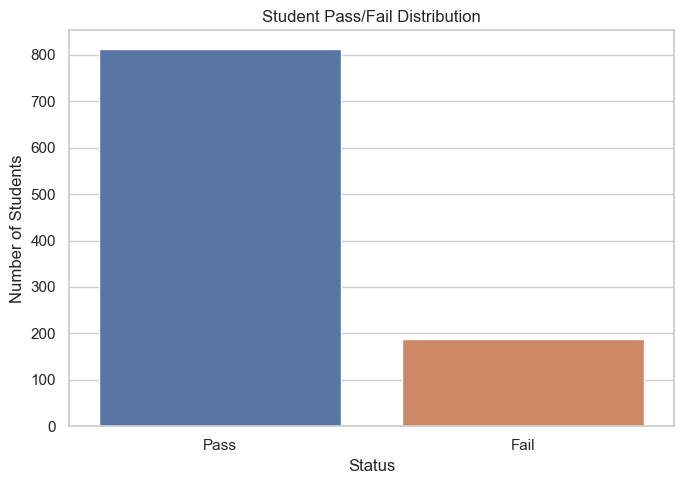

In [64]:
plt.figure(figsize=(7, 5))

sns.countplot( data=SP, x='pass_status')

plt.title('Student Pass/Fail Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()

# Pass Rate

In [65]:
pass_rate = (
    SP['pass_status']
    .value_counts(normalize=True)
    * 100
)

pass_rate.round(2)

pass_status
Pass    81.2
Fail    18.8
Name: proportion, dtype: float64

# Pass Rate by Gender

In [66]:

pass_by_gender = pd.crosstab(
    SP['gender'],
    SP['pass_status'],
    normalize='index'
) * 100

print(pass_by_gender.round(2))

pass_status   Fail   Pass
gender                   
female       17.18  82.82
male         20.54  79.46


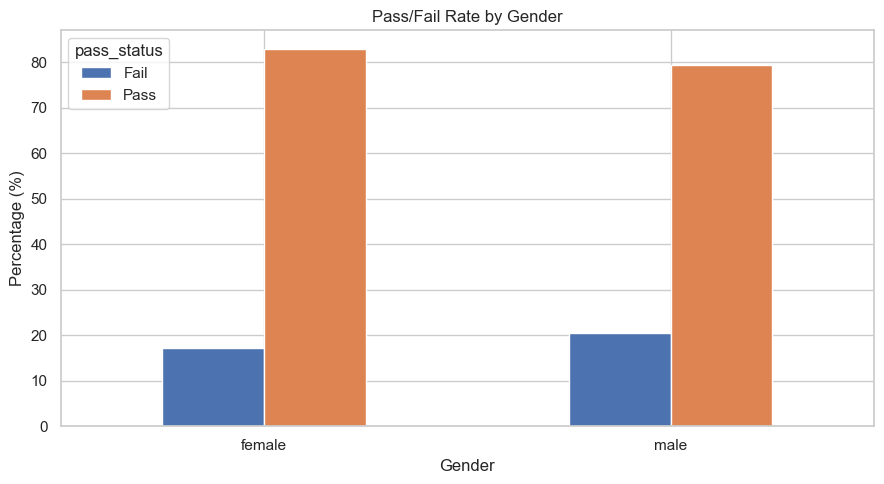

In [67]:
pass_by_gender.plot(kind='bar',figsize=(9, 5))

plt.title('Pass/Fail Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Pass Rate by Test Preparation

In [68]:
pass_by_prep = pd.crosstab(
    SP['test preparation course'],
    SP['pass_status'],
    normalize='index'
) * 100

print(pass_by_prep.round(2))

pass_status               Fail   Pass
test preparation course              
completed                10.06  89.94
none                     23.68  76.32


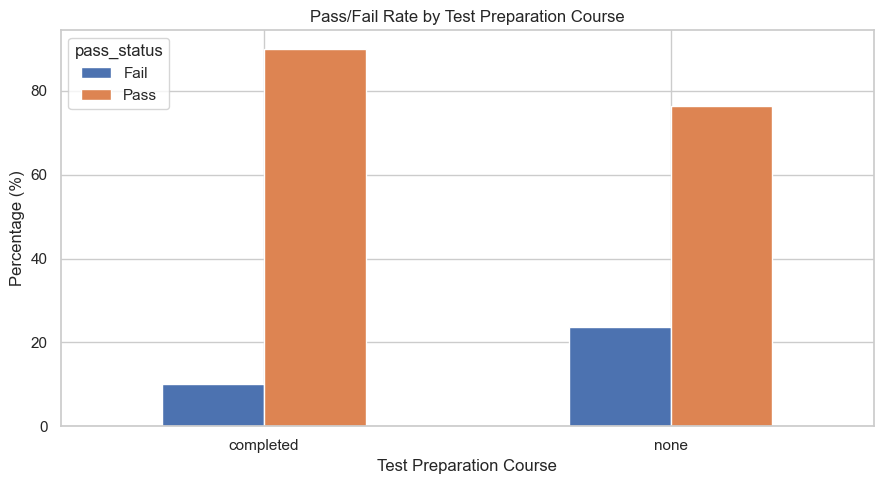

In [69]:
pass_by_prep.plot(kind='bar',figsize=(9, 5))

plt.title('Pass/Fail Rate by Test Preparation Course')
plt.xlabel('Test Preparation Course')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Top 10 Students

In [70]:
SP.columns = [col.strip() for col in SP.columns]

SP['average score'] = SP[['math score', 'reading score', 'writing score']].mean(axis=1)

top_10 = SP.sort_values('average score', ascending=False).head(10)

top_10[
    [
        'gender',
        'race/ethnicity',
        'parental level of education',
        'test preparation course',
        'math score',
        'reading score',
        'writing score',
        'average score'
    ]
]

,gender,race/ethnicity,parental level of education,test preparation course,math score,reading score,writing score,average score
916,male,group E,bachelor's degree,completed,100,100,100,100.000000
458,female,group E,bachelor's degree,none,100,100,100,100.000000
962,female,group E,associate's degree,none,100,100,100,100.000000
114,female,group E,bachelor's degree,completed,99,100,100,99.666667
179,female,group D,some high school,completed,97,100,100,99.000000
712,female,group D,some college,none,98,100,99,99.000000
165,female,group C,bachelor's degree,completed,96,100,100,98.666667
625,male,group D,some college,completed,100,97,99,98.666667
903,female,group D,bachelor's degree,completed,93,100,100,97.666667
149,male,group E,associate's degree,completed,100,100,93,97.666667


# Bottom 10 Students

In [71]:
bottom_10 = SP.sort_values('average score',ascending=True).head(10)

bottom_10[
    [
        'gender',
        'race/ethnicity',
        'parental level of education',
        'test preparation course',
        'math score',
        'reading score',
        'writing score',
        'average score'
    ]
]

,gender,race/ethnicity,parental level of education,test preparation course,math score,reading score,writing score,average score
59,female,group C,some high school,none,0,17,10,9.000000
980,female,group B,high school,none,8,24,23,18.333333
596,male,group B,high school,none,30,24,15,23.000000
327,male,group A,some college,none,28,23,19,23.333333
76,male,group E,some high school,none,30,26,22,26.000000
17,female,group B,some high school,none,18,32,28,26.000000
601,female,group C,high school,none,29,29,30,29.333333
787,female,group B,some college,none,19,38,32,29.666667
338,female,group B,some high school,none,24,38,27,29.666667
211,male,group C,some college,none,35,28,27,30.000000


# Best and Worst Subject

In [72]:

subject_average = pd.Series({
    'Math': SP['math score'].mean(),
    'Reading': SP['reading score'].mean(),
    'Writing': SP['writing score'].mean()
})

best_subject = subject_average.idxmax()
worst_subject = subject_average.idxmin()

print("Average scores:")
print(subject_average.round(2))

print("\nBest performing subject:", best_subject)
print("Lowest performing subject:", worst_subject)

Average scores:
Math       66.09
Reading    69.17
Writing    68.05
dtype: float64

Best performing subject: Reading
Lowest performing subject: Math


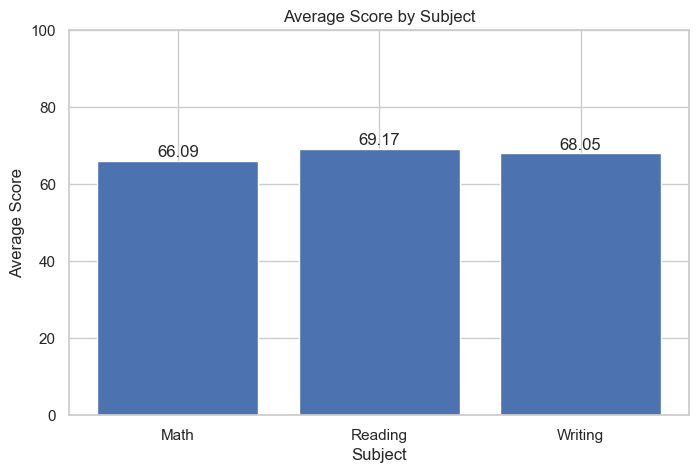

In [73]:
plt.figure(figsize=(8, 5))

subject_averages = {
    'Math':66.09,
 'Reading':69.17,
 'Writing':68.05
}

subjects = list(subject_averages.keys())
averages = list(subject_averages.values())

bars = plt.bar(subjects, averages)

plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.ylim(0, 100)

for bar, value in zip(bars, averages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

# Interpretation

In [75]:
print(
    f"Students performed best in {best_subject}, "
    f"with an average score of {subject_averages[best_subject]:.2f}."
)

print(
    f"The lowest average performance was recorded in {worst_subject}, "
    f"with an average score of {subject_averages[worst_subject]:.2f}."
)

Students performed best in Reading, with an average score of 69.17.
The lowest average performance was recorded in Math, with an average score of 66.09.


# REPORT

# Best and Worst Subject

The analysis compares the average scores in Mathematics, Reading, and Writing.

The subject with the highest average score is considered the **best-performing subject**, while the subject with the lowest average score is considered the **worst-performing subject**.

This comparison helps identify areas where students perform strongly and subjects that may require additional academic support.